# Phân Tích và Khám Phá Dữ Liệu (EDA) - Dự án Dự báo Nhu cầu Thuê Xe Đạp

Đây là Notebook thực hiện bước đầu tiên của dự án: Phân tích và khám phá dữ liệu (Exploratory Data Analysis - EDA) cho bộ dữ liệu chia sẻ xe đạp theo giờ (UCI Bike Sharing Dataset, file `hour.csv`).

Nội dung chính trong file này bao gồm:
1. Đọc và kiểm tra cấu trúc dữ liệu cơ bản (kiểm tra kiểu dữ liệu, giá trị thiếu, và kiểm tra tính liên tục, lấy mẫu đều theo giờ).
2. Phân tích phân phối của biến mục tiêu (`cnt`) và giải thích lý do cần biến đổi logarit.
3. Khảo sát nhu cầu thuê xe theo thời gian (theo giờ trong ngày, ngày trong tuần, tháng, mùa vụ, và theo thời gian thực dài hạn).
4. Phân tích các yếu tố thời tiết ảnh hưởng đến lượng xe thuê (nhiệt độ, độ ẩm, tốc độ gió).
5. Đánh giá độ tương quan giữa các biến thông qua ma trận tương quan để phát hiện đa cộng tuyến.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

# Cấu hình hiển thị cho biểu đồ
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = [10, 6]
plt.rcParams['font.size'] = 12

# Đảm bảo thư mục lưu biểu đồ đã tồn tại
os.makedirs("../figures", exist_ok=True)

## 1. Đọc và kiểm tra cấu trúc dữ liệu ban đầu
Chúng ta sẽ load dữ liệu từ file `data/raw/hour.csv` và kiểm tra các thông tin cơ bản: số dòng, số cột, kiểu dữ liệu và xem có giá trị null nào không.

In [2]:
# Đường dẫn dữ liệu
data_path = "../data/raw/hour.csv"
df = pd.read_csv(data_path)

# Xem 5 dòng đầu tiên
df.head()

,instant,dteday,season,yr,mnth,hr,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
0,1,2011-01-01,1,0,1,0,0,6,0,1,0.24,0.2879,0.81,0.0,3,13,16
1,2,2011-01-01,1,0,1,1,0,6,0,1,0.22,0.2727,0.80,0.0,8,32,40
2,3,2011-01-01,1,0,1,2,0,6,0,1,0.22,0.2727,0.80,0.0,5,27,32
3,4,2011-01-01,1,0,1,3,0,6,0,1,0.24,0.2879,0.75,0.0,3,10,13
4,5,2011-01-01,1,0,1,4,0,6,0,1,0.24,0.2879,0.75,0.0,0,1,1


In [3]:
# Kiểm tra số dòng, cột và kiểu dữ liệu
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 17379 entries, 0 to 17378
Data columns (total 17 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   instant     17379 non-null  int64  
 1   dteday      17379 non-null  str    
 2   season      17379 non-null  int64  
 3   yr          17379 non-null  int64  
 4   mnth        17379 non-null  int64  
 5   hr          17379 non-null  int64  
 6   holiday     17379 non-null  int64  
 7   weekday     17379 non-null  int64  
 8   workingday  17379 non-null  int64  
 9   weathersit  17379 non-null  int64  
 10  temp        17379 non-null  float64
 11  atemp       17379 non-null  float64
 12  hum         17379 non-null  float64
 13  windspeed   17379 non-null  float64
 14  casual      17379 non-null  int64  
 15  registered  17379 non-null  int64  
 16  cnt         17379 non-null  int64  
dtypes: float64(4), int64(12), str(1)
memory usage: 2.3 MB


In [4]:
# Kiểm tra giá trị khuyết thiếu (Missing values)
df.isnull().sum()

instant       0
dteday        0
season        0
yr            0
mnth          0
hr            0
holiday       0
weekday       0
workingday    0
weathersit    0
temp          0
atemp         0
hum           0
windspeed     0
casual        0
registered    0
cnt           0
dtype: int64

### 1.2. Kiểm tra tính liên tục và lấy mẫu đều đặn theo giờ
Vì đây là bài toán dự báo chuỗi thời gian (time series), tính liên tục và tần suất lấy mẫu là vô cùng quan trọng. Chúng ta sẽ ghép cột ngày (`dteday`) và giờ (`hr`) lại để tạo mốc thời gian chi tiết, sau đó kiểm tra xem dữ liệu có được lấy mẫu đều đặn mỗi giờ một lần hay có khoảng trống (gaps) nào không.

In [5]:
# Tạo cột datetime hoàn chỉnh từ dteday và hr
df['datetime'] = pd.to_datetime(df['dteday']) + pd.to_timedelta(df['hr'], unit='h')

# Sắp xếp dữ liệu theo thứ tự thời gian tăng dần
df = df.sort_values('datetime').reset_index(drop=True)

# Tính khoảng cách thời gian giữa các dòng liên tiếp
time_diffs = df['datetime'].diff()

print("Thống kê các khoảng thời gian chênh lệch giữa các dòng liên tiếp:")
print(time_diffs.value_counts())

# Kiểm tra tổng số lượng giờ bị thiếu trong chuỗi thời gian
min_time = df['datetime'].min()
max_time = df['datetime'].max()
expected_hours = int((max_time - min_time).total_seconds() / 3600 + 1)
actual_hours = len(df)
missing_hours = expected_hours - actual_hours

print(f"\nThời gian bắt đầu: {min_time}")
print(f"Thời gian kết thúc: {max_time}")
print(f"Số lượng giờ dự kiến (liên tục): {expected_hours}")
print(f"Số lượng giờ thực tế ghi nhận: {actual_hours}")
print(f"Số lượng giờ bị thiếu (gaps): {missing_hours} giờ ({missing_hours/expected_hours*100:.2f}%)")

Thống kê các khoảng thời gian chênh lệch giữa các dòng liên tiếp:
datetime
0 days 01:00:00    17303
0 days 02:00:00       64
0 days 03:00:00        6
0 days 13:00:00        1
0 days 23:00:00        1
0 days 07:00:00        1
0 days 14:00:00        1
1 days 13:00:00        1
Name: count, dtype: int64

Thời gian bắt đầu: 2011-01-01 00:00:00
Thời gian kết thúc: 2012-12-31 23:00:00
Số lượng giờ dự kiến (liên tục): 17544
Số lượng giờ thực tế ghi nhận: 17379
Số lượng giờ bị thiếu (gaps): 165 giờ (0.94%)


### Nhận xét ban đầu về cấu trúc & tính liên tục:
- Dữ liệu có tổng cộng **17,379 dòng** và **17 cột**.
- Bộ dữ liệu rất sạch, **không có giá trị khuyết thiếu (missing value)** nào ở tất cả các cột.
- **Về tính liên tục của chuỗi thời gian**:
  - Khoảng cách thời gian phổ biến nhất giữa 2 dòng liên tiếp là **1 giờ** (17,303 lần).
  - Tuy nhiên, bộ dữ liệu **không hoàn toàn liên tục**. Có 64 lần cách nhau 2 giờ, 6 lần cách nhau 3 giờ, và một số khoảng trống lớn hơn (lên tới hơn 1 ngày).
  - Tổng số giờ dự kiến từ đầu chuỗi đến cuối chuỗi là 17,544 giờ, nhưng thực tế chỉ có 17,379 giờ. Như vậy, bộ dữ liệu bị **khuyết mất 165 giờ** (khoảng 0.94% tổng chuỗi thời gian).
  - **Đề xuất**: Thành viên phụ trách Feature Engineering (Thành viên 2) cần chú ý xử lý các khoảng thiếu này (ví dụ: điền khuyết bằng phương pháp nội suy hoặc điền bằng giá trị trước đó) để tránh lỗi lệch pha thời gian khi tạo các đặc trưng trễ (lag features).

## 2. Phân tích biến mục tiêu (`cnt`)
Biến `cnt` là tổng số lượng xe đạp được thuê trong một giờ. Đây là biến mục tiêu mà nhóm cần dự báo. Hãy vẽ biểu đồ phân phối để xem phân bố của biến này.

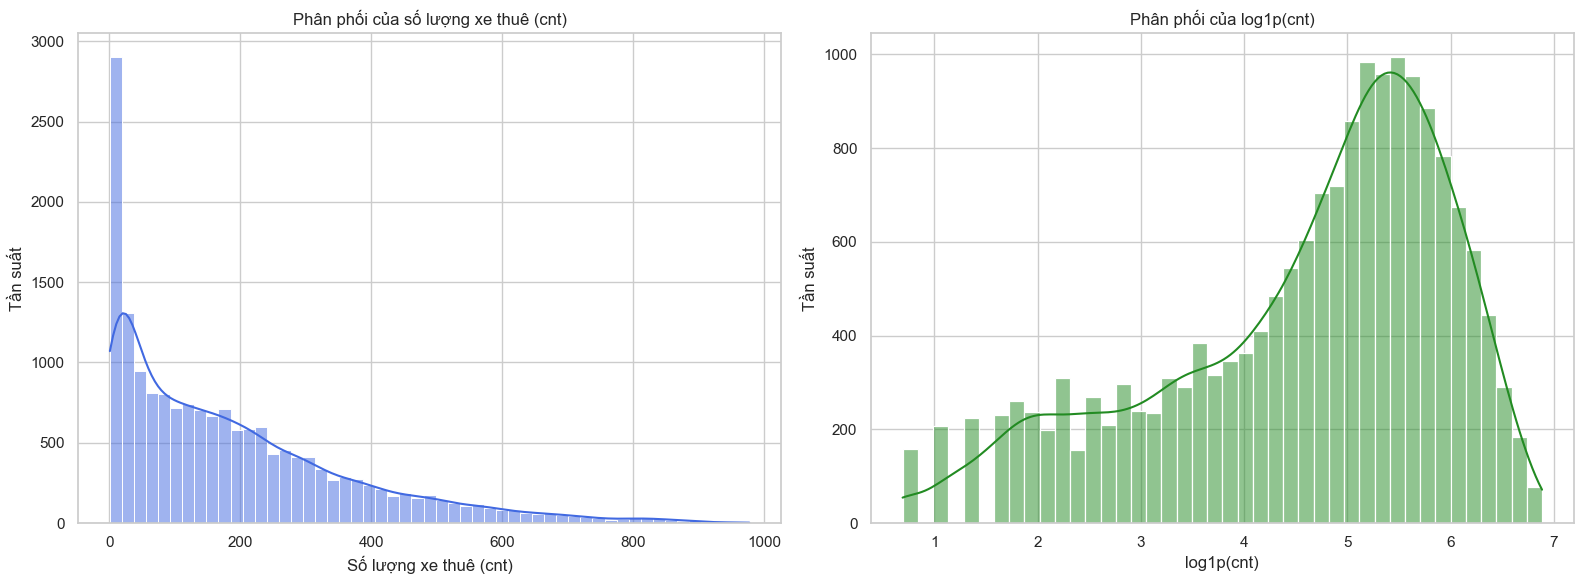

Skewness gốc: 1.2774116037490573
Skewness sau khi log1p: -0.8181803744437346


In [6]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Vẽ phân phối gốc của biến cnt
sns.histplot(df['cnt'], kde=True, ax=axes[0], color='royalblue')
axes[0].set_title('Phân phối của số lượng xe thuê (cnt)')
axes[0].set_xlabel('Số lượng xe thuê (cnt)')
axes[0].set_ylabel('Tần suất')

# Vẽ phân phối sau khi log-transform
sns.histplot(np.log1p(df['cnt']), kde=True, ax=axes[1], color='forestgreen')
axes[1].set_title('Phân phối của log1p(cnt)')
axes[1].set_xlabel('log1p(cnt)')
axes[1].set_ylabel('Tần suất')

plt.tight_layout()
# Lưu biểu đồ
plt.savefig("../figures/eda_demand_distribution.png", dpi=150)
plt.show()

# Tính độ lệch (Skewness)
print("Skewness gốc:", df['cnt'].skew())
print("Skewness sau khi log1p:", np.log1p(df['cnt']).skew())

### Nhận xét về biến mục tiêu:
- Phân phối gốc của `cnt` bị **lệch phải rất nhiều** (Skewness khoảng 1.27). Phần lớn các giờ có lượng thuê xe thấp (dưới 200 xe/giờ), trong khi có một số ít giờ cao điểm lượng xe lên tới gần 1000 xe.
- Khi áp dụng phép biến đổi logarit $y = \log(1 + cnt)$, phân phối trở nên cân đối hơn, gần với phân phối chuẩn hơn nhiều (Skewness giảm xuống còn khoảng -0.8).
- **Đề xuất**: Trong quá trình huấn luyện các mô hình học máy (như Linear Regression hay Neural Networks), việc dự báo trên biến mục tiêu đã biến đổi logarit thường sẽ giúp mô hình hội tụ tốt hơn và giảm tác động từ các điểm dữ liệu quá lớn (outliers).

## 3. Khảo sát nhu cầu thuê xe theo thời gian
Chúng ta sẽ phân tích xem lượng xe thuê thay đổi thế nào theo các biến thời gian: giờ trong ngày (`hr`), ngày trong tuần (`weekday`), mùa (`season`), năm (`yr`), và ngày làm việc vs ngày nghỉ (`workingday`).

### 3.1. Nhu cầu thuê xe theo giờ trong ngày (hr)
Nhu cầu thuê xe chắc chắn sẽ biến động mạnh giữa các giờ trong ngày. Chúng ta hãy so sánh biến động này giữa ngày làm việc (`workingday = 1`) và ngày nghỉ/cuối tuần (`workingday = 0`).

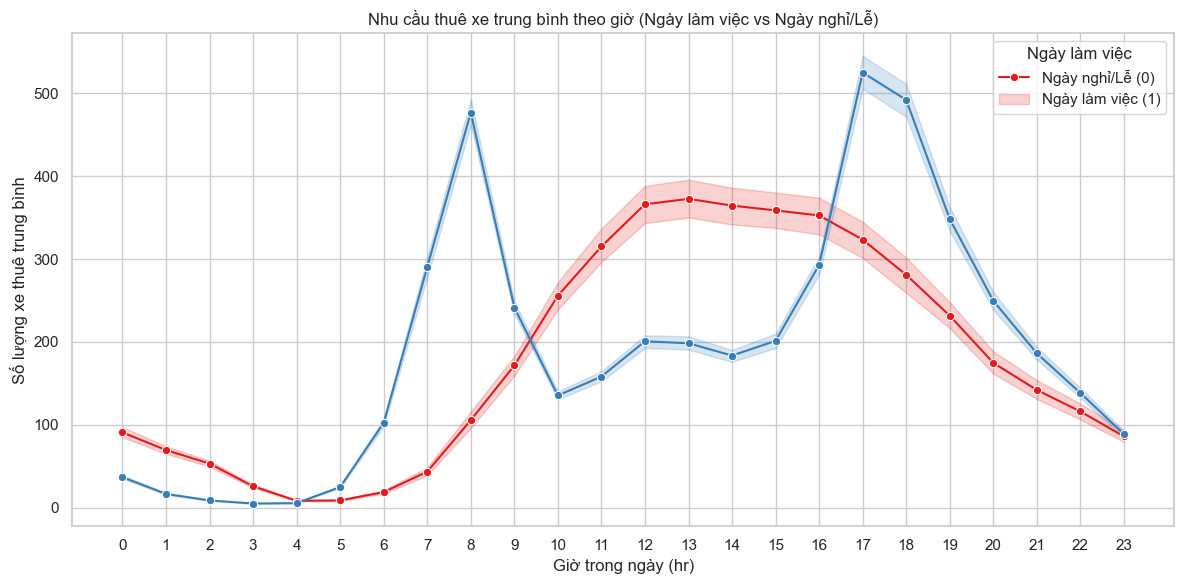

In [7]:
plt.figure(figsize=(12, 6))
sns.lineplot(data=df, x='hr', y='cnt', hue='workingday', errorbar='ci', palette='Set1', marker='o')
plt.title('Nhu cầu thuê xe trung bình theo giờ (Ngày làm việc vs Ngày nghỉ/Lễ)')
plt.xlabel('Giờ trong ngày (hr)')
plt.ylabel('Số lượng xe thuê trung bình')
plt.legend(title='Ngày làm việc', labels=['Ngày nghỉ/Lễ (0)', 'Ngày làm việc (1)'])
plt.xticks(range(0, 24))
plt.tight_layout()
plt.savefig("../figures/eda_demand_by_hour.png", dpi=150)
plt.show()

### Nhận xét:
- Biểu đồ cho thấy sự khác biệt rõ rệt về hành vi thuê xe giữa ngày đi làm và ngày nghỉ:
  - **Ngày làm việc (đường màu xanh)**: Có hai đỉnh rất rõ ràng vào khung giờ đi làm/tan tầm là **8 giờ sáng** và **17-18 giờ chiều**. Đây là lúc người dân thuê xe đạp để di chuyển đi học, đi làm.
  - **Ngày nghỉ/Lễ (đường màu đỏ)**: Nhu cầu thuê xe tăng dần từ sáng và đạt đỉnh vào giữa ngày từ **12 giờ đến 16 giờ chiều**. Hành vi này phù hợp với nhu cầu vui chơi giải trí, dã ngoại cuối tuần.
- Điều này chứng tỏ biến tương tác giữa `hr` và `workingday` sẽ là một đặc trưng cực kỳ quan trọng cho các mô hình học máy sau này.

### 3.2. Nhu cầu thuê xe theo ngày trong tuần (weekday)
Chúng ta hãy xem phân bố lượng xe thuê theo từng ngày trong tuần (từ Chủ Nhật đến Thứ Bảy).

C:\Users\ycao7\AppData\Local\Temp\ipykernel_4124\669121681.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='weekday', y='cnt', palette='Set3')


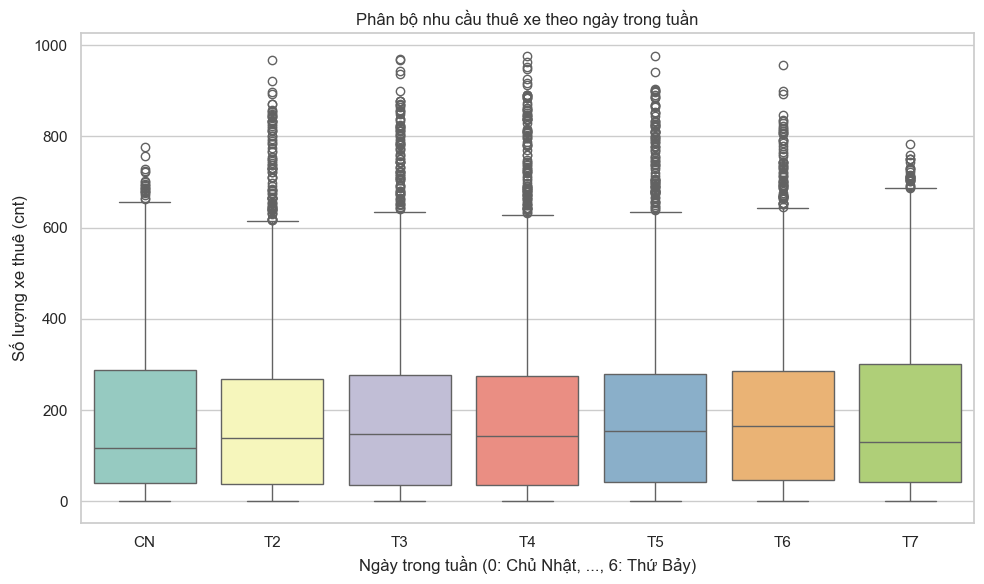

In [8]:
plt.figure(figsize=(10, 6))
sns.boxplot(data=df, x='weekday', y='cnt', palette='Set3')
plt.title('Phân bộ nhu cầu thuê xe theo ngày trong tuần')
plt.xlabel('Ngày trong tuần (0: Chủ Nhật, ..., 6: Thứ Bảy)')
plt.ylabel('Số lượng xe thuê (cnt)')
plt.xticks(ticks=range(7), labels=['CN', 'T2', 'T3', 'T4', 'T5', 'T6', 'T7'])
plt.tight_layout()
plt.savefig("../figures/eda_demand_by_weekday.png", dpi=150)
plt.show()

### Nhận xét:
- Nhìn chung, mức phân bố lượng xe thuê ở các ngày trong tuần tương đối đồng đều.
- Tuy nhiên, ta thấy số lượng các điểm outlier (những giờ có lượng xe thuê đột biến cao) xuất hiện nhiều hơn ở các ngày trong tuần (Thứ Hai đến Thứ Sáu) so với cuối tuần, tương thích với nhu cầu giờ cao điểm lớn trong ngày đi làm.

### 3.3. Nhu cầu thuê xe theo mùa (`season`) và tình trạng thời tiết (`weathersit`)
Chúng ta phân tích nhu cầu thuê xe dưới tác động của mùa vụ và thời tiết.

C:\Users\ycao7\AppData\Local\Temp\ipykernel_4124\3301048081.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='season', y='cnt', ax=axes[0], palette='coolwarm')
C:\Users\ycao7\AppData\Local\Temp\ipykernel_4124\3301048081.py:8: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[0].set_xticklabels(['Xuân', 'Hạ', 'Thu', 'Đông'])
C:\Users\ycao7\AppData\Local\Temp\ipykernel_4124\3301048081.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='weathersit', y='cnt', ax=axes[1], palette='viridis')
C:\Users\ycao7\AppData\Local\Temp\ipykernel_4124\3301048081.py:15: UserWarning: set_ticklabels(

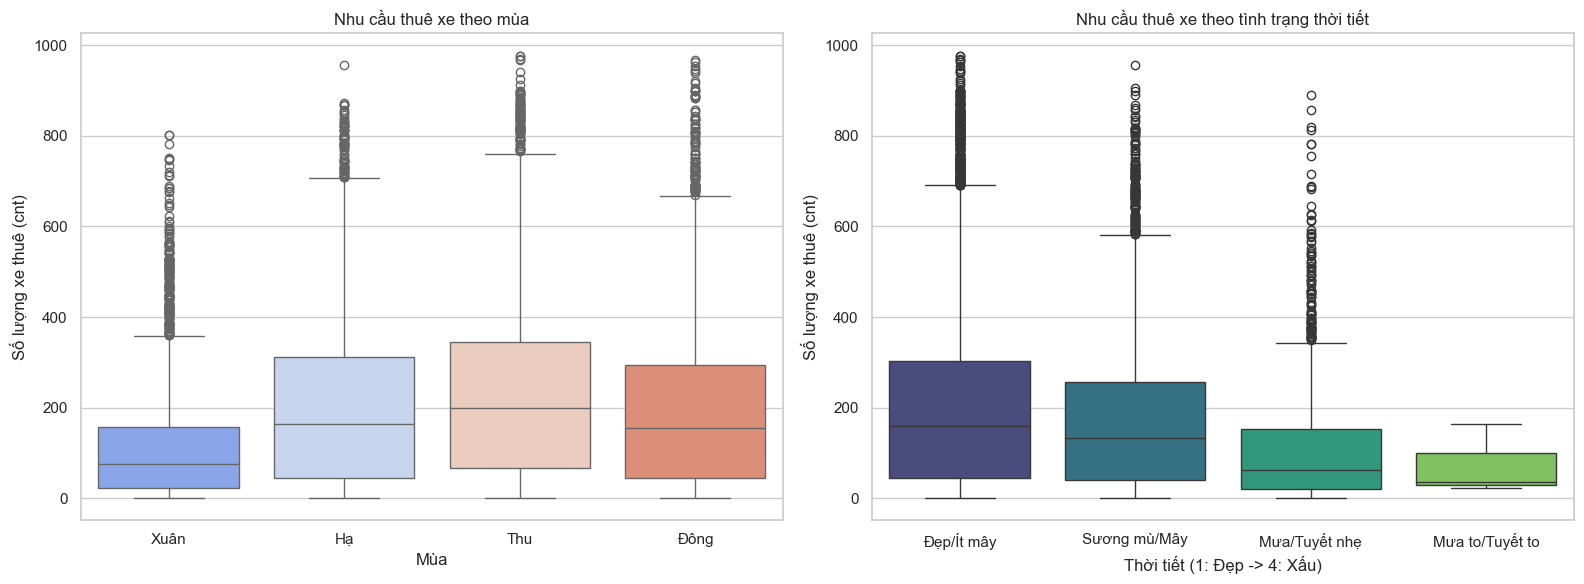

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Vẽ boxplot theo mùa
sns.boxplot(data=df, x='season', y='cnt', ax=axes[0], palette='coolwarm')
axes[0].set_title('Nhu cầu thuê xe theo mùa')
axes[0].set_xlabel('Mùa')
axes[0].set_ylabel('Số lượng xe thuê (cnt)')
axes[0].set_xticklabels(['Xuân', 'Hạ', 'Thu', 'Đông'])

# Vẽ boxplot theo tình trạng thời tiết
sns.boxplot(data=df, x='weathersit', y='cnt', ax=axes[1], palette='viridis')
axes[1].set_title('Nhu cầu thuê xe theo tình trạng thời tiết')
axes[1].set_xlabel('Thời tiết (1: Đẹp -> 4: Xấu)')
axes[1].set_ylabel('Số lượng xe thuê (cnt)')
axes[1].set_xticklabels(['Đẹp/Ít mây', 'Sương mù/Mây', 'Mưa/Tuyết nhẹ', 'Mưa to/Tuyết to'])

plt.tight_layout()
plt.savefig("../figures/eda_demand_by_season.png", dpi=150)
plt.show()

### Nhận xét:
- **Theo mùa**: Lượng xe thuê thấp nhất vào mùa Xuân (do thời tiết lạnh giá đầu năm). Nhu cầu tăng mạnh nhất vào mùa Hạ (mùa 2) và mùa Thu (mùa 3), sau đó giảm nhẹ vào mùa Đông khi thời tiết lạnh trở lại.
- **Theo thời tiết**: Thời tiết ảnh hưởng trực tiếp đến quyết định thuê xe đạp. Lượng thuê xe cao nhất khi trời đẹp, ít mây (`weathersit = 1`). Khi thời tiết xấu hơn (sương mù, mưa rào, tuyết rơi), nhu cầu giảm hẳn. Đặc biệt khi trời mưa to hoặc tuyết dày (`weathersit = 4`), lượng thuê xe gần như bằng không.

### 3.4. Nhu cầu thuê xe theo thời gian thực (Time Series Line Plot)
Để biểu diễn đặc trưng chuỗi thời gian liên tục qua các ngày tháng năm, chúng ta vẽ hai biểu đồ đường:
1. **Đường xu hướng dài hạn (Rolling Mean)**: Lấy trung bình trượt trong 1 tuần (168 giờ) của cả giai đoạn 2011-2012 để khử tính chu kỳ ngắn hạn và quan sát rõ sự biến đổi theo mùa/năm.
2. **Đường chi tiết ngắn hạn**: Trích lọc 3 tuần đầu tiên của năm 2011 để quan sát rõ quy luật chu kỳ ngày/đêm.

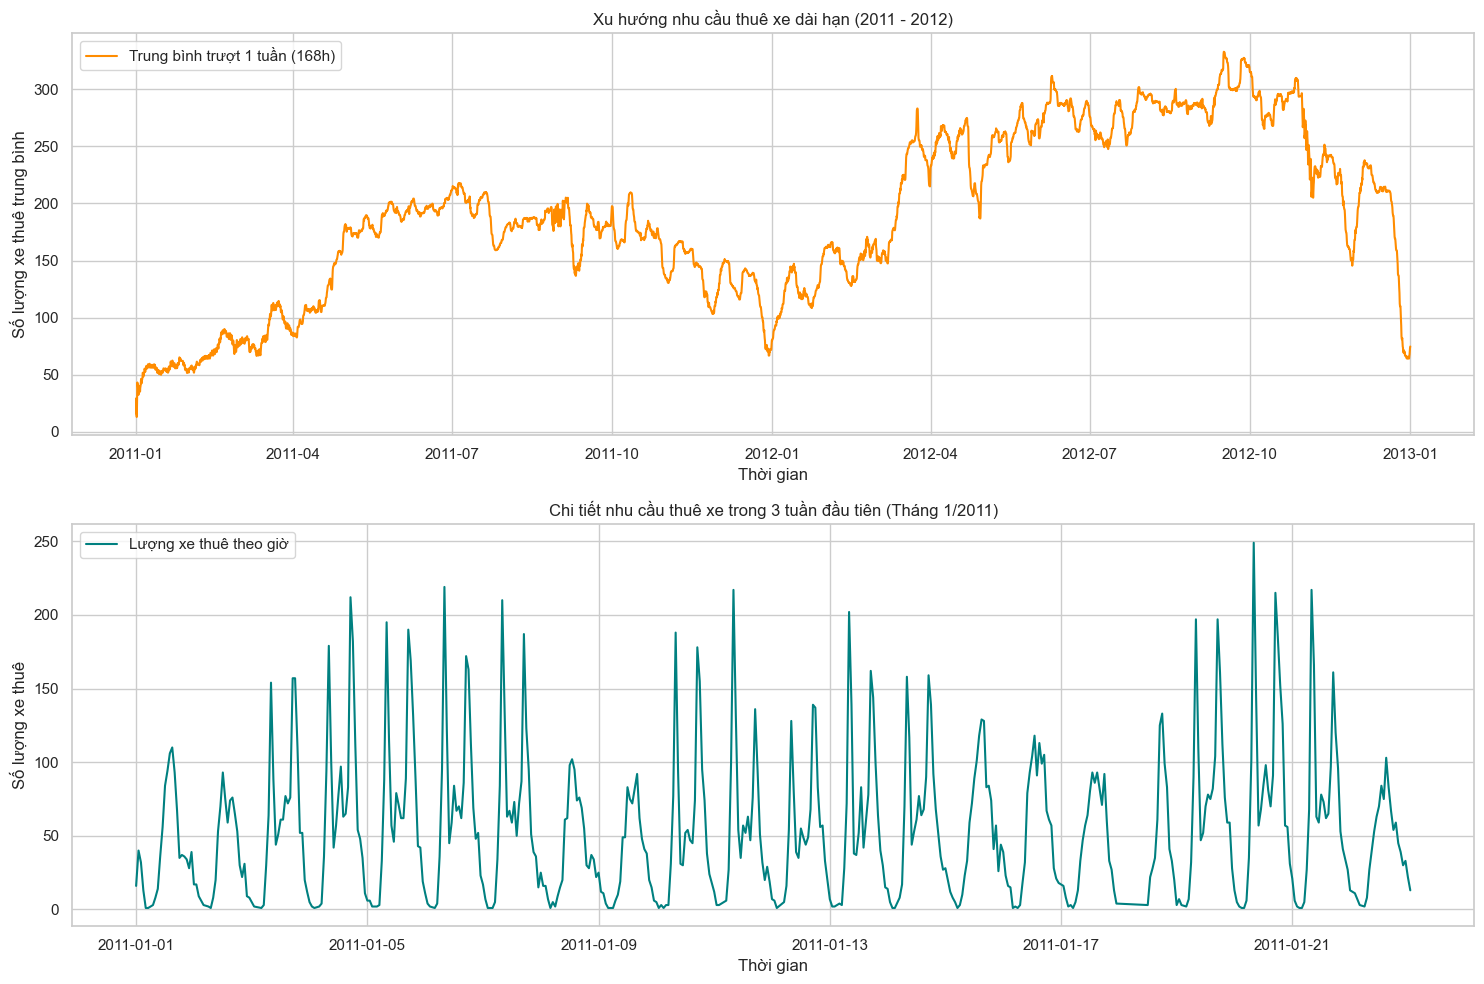

In [10]:
fig, axes = plt.subplots(2, 1, figsize=(15, 10))

# 1. Đường xu hướng dài hạn (Rolling Mean 168h - 1 tuần)
df_sorted = df.sort_values('datetime')
df_sorted['rolling_cnt'] = df_sorted['cnt'].rolling(window=168, min_periods=1).mean()
axes[0].plot(df_sorted['datetime'], df_sorted['rolling_cnt'], color='darkorange', label='Trung bình trượt 1 tuần (168h)')
axes[0].set_title('Xu hướng nhu cầu thuê xe dài hạn (2011 - 2012)')
axes[0].set_xlabel('Thời gian')
axes[0].set_ylabel('Số lượng xe thuê trung bình')
axes[0].legend()

# 2. Chi tiết 3 tuần đầu tiên (để thấy rõ chu kỳ ngày đêm)
sample_df = df_sorted.head(24 * 21) # 21 ngày
axes[1].plot(sample_df['datetime'], sample_df['cnt'], color='teal', label='Lượng xe thuê theo giờ')
axes[1].set_title('Chi tiết nhu cầu thuê xe trong 3 tuần đầu tiên (Tháng 1/2011)')
axes[1].set_xlabel('Thời gian')
axes[1].set_ylabel('Số lượng xe thuê')
axes[1].legend()

plt.tight_layout()
# Lưu biểu đồ
plt.savefig("../figures/eda_demand_over_time.png", dpi=150)
plt.show()

### Nhận xét về biểu đồ thời gian thực:
- **Xu hướng dài hạn**: Lượng thuê xe tăng dần từ 2011 sang 2012 (thể hiện sự phát triển quy mô dịch vụ). Tính mùa vụ hiện lên rất rõ ràng theo hình sóng: nhu cầu đạt đỉnh vào khoảng giữa mỗi năm (mùa hè/thu) và chạm đáy vào cuối năm/đầu năm sau (mùa đông/xuân).
- **Quy luật ngắn hạn**: Biểu đồ chi tiết 3 tuần thể hiện chu kỳ lặp lại rất đều đặn từng ngày. Mỗi ngày có các đỉnh nhọn đại diện cho các giờ cao điểm và chạm đáy vào ban đêm (khoảng 0h - 4h sáng).

## 4. Phân tích mối tương quan giữa các biến số
Chúng ta sẽ tính toán ma trận tương quan Pearson để đánh giá mối liên hệ tuyến tính giữa các biến số liên tục (nhiệt độ, độ ẩm, tốc độ gió) và biến mục tiêu `cnt`.

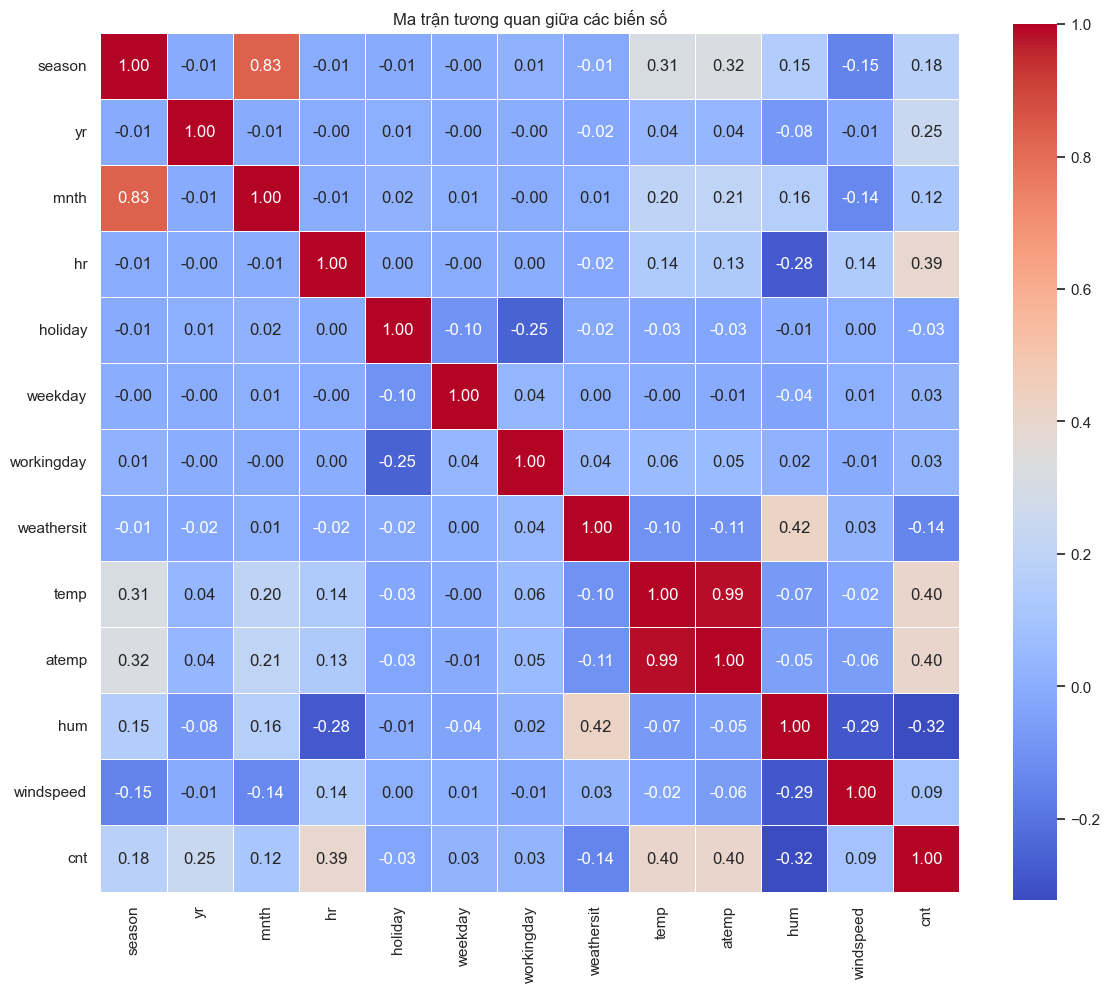

In [11]:
# Chọn các cột số quan trọng để vẽ ma trận tương quan
cols_to_corr = ['season', 'yr', 'mnth', 'hr', 'holiday', 'weekday', 'workingday', 'weathersit', 'temp', 'atemp', 'hum', 'windspeed', 'cnt']
corr_matrix = df[cols_to_corr].corr()

plt.figure(figsize=(12, 10))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=.5, square=True)
plt.title('Ma trận tương quan giữa các biến số')
plt.tight_layout()
plt.savefig("../figures/eda_correlation_matrix.png", dpi=150)
plt.show()

### Nhận xét quan trọng về tương quan:
1. **Mối tương quan với biến mục tiêu `cnt`**:
   - Biến `temp` (nhiệt độ) và `atemp` (nhiệt độ cảm nhận) có tương quan dương mạnh nhất với `cnt` (khoảng 0.40). Điều này cho thấy khi trời ấm lên, nhu cầu thuê xe đạp tăng cao.
   - Biến `hr` (giờ) có tương quan dương ở mức 0.39, phản ánh sự biến động mạnh của lượng xe thuê theo các khung giờ trong ngày.
   - Biến `hum` (độ ẩm) có tương quan âm (-0.32), tức là độ ẩm càng cao (trời âm u hoặc oi bức) thì người dân càng ít thuê xe đạp.
   - Biến `weathersit` có tương quan âm (-0.14), chứng tỏ thời tiết xấu làm giảm lượng thuê xe.

2. **Hiện tượng đa cộng tuyến (Multicollinearity)**:
   - Hai biến `temp` (nhiệt độ thực tế) và `atemp` (nhiệt độ cảm nhận) có tương quan tuyến tính gần như tuyệt đối (**0.99**).
   - Việc giữ lại cả 2 biến này trong các mô hình hồi quy tuyến tính có thể gây ra hiện tượng đa cộng tuyến, làm sai lệch các hệ số ước lượng của mô hình.
   - **Đề xuất**: Thành viên phụ trách làm feature engineering (Thành viên 2) nên cân nhắc loại bỏ một trong hai biến này (ví dụ chỉ giữ lại `temp`) hoặc tạo một đặc trưng kết hợp để tránh trùng lặp thông tin.

## 5. Kết luận chung từ quá trình EDA
Qua các phân tích trên, Thành viên 1 rút ra một số kết luận định hướng cho các bước tiếp theo của nhóm:
1. **Biến mục tiêu**: Nên áp dụng log-transform (`log1p`) khi huấn luyện các mô hình để tránh bị ảnh hưởng bởi độ lệch lớn của dữ liệu thực tế.
2. **Xử lý tính liên tục**: Bộ dữ liệu bị thiếu 165 giờ. Cần thực hiện chèn dữ liệu (imputation) cho các giờ bị thiếu này để tạo chuỗi thời gian liên tục trước khi tạo các biến trễ (lags).
3. **Feature Engineering (Thành viên 2)**:
   - Cần khai thác các biến tương tác quan trọng, đặc biệt là sự kết hợp giữa giờ (`hr`) và ngày làm việc (`workingday`).
   - Nên loại bỏ biến `atemp` hoặc xử lý đa cộng tuyến vì nó bị trùng lặp thông tin với `temp` (tương quan 0.99).
   - Các biến phân loại như `season`, `weathersit`, `weekday` nên được mã hóa phù hợp (ví dụ: One-Hot Encoding hoặc tạo các biến tuần hoàn dạng Fourier features).
4. **Huấn luyện mô hình (Thành viên 3)**:
   - Nhu cầu thuê xe có tính chu kỳ rất rõ rệt theo ngày (24 giờ) và theo tuần (7 ngày) cũng như theo mùa. Các mô hình chuỗi thời gian như LSTM, GRU hoặc các mô hình học máy có tạo biến trễ (lag features) sẽ khai thác được rất tốt các tính chất tuần hoàn này.